# Notebook 3 — Hypothesis Testing with Permutation Tests

**Hypothesis testing**: is a method of statistical inference used to decide whether the data provide sufficient evidence to reject a particular hypothesis. A way to ask "could this pattern have arisen by chance?

We'll use **permutation test** — a non-parametric, exact statistical method that evaluates significance by shuffling data labels to calculate a null distribution, rather than assuming any distribution.

---
## 1. Setup

In [57]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme()
np.random.seed(42)

DATA = os.path.join('..', 'data')
SUB_DIR = os.path.join(DATA, 'subfamilies')

def read_fasta(path):
    seqs = {}
    header = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                header = line[1:].split()[0]
                seqs[header] = ''
            elif header:
                seqs[header] += line
    return seqs

---
## 2. What is a permutation test?

Assume you measure the body mass of 12 mammals. Five are
echolocators, seven are not. The echolocators happen to have a
**higher average mass**. Is this significant, or could be explained by chance?

The permutation test asks if the "echolocator"
labels were not related to mass, how often would we see a
difference as large as this just by randomly mixing the labels?

In [72]:
# Simulated body mass data (kg, made up for illustration)
masses = np.array([39, 42, 37, 50, 38, 45, 22, 31, 27, 33, 40, 36])
labels = np.array(['echo']*5 + ['non']*7)

echo_mean = masses[labels == 'echo'].mean()
non_mean  = masses[labels == 'non'].mean()
observed_diff = echo_mean - non_mean

print(f"Echolocator mean: {echo_mean:.1f} kg")
print(f"Non-echolocator mean: {non_mean:.1f} kg")
print(f"Observed difference: {observed_diff:.1f} kg")

Echolocator mean: 41.2 kg
Non-echolocator mean: 33.4 kg
Observed difference: 7.8 kg


Is the difference of ~7 kg statistically significant?

In [81]:
# np.random.seed(42)
n_perm = 10000
null_diffs = np.zeros(n_perm)

for i in range(n_perm):
    shuffled = np.random.permutation(labels)
    echo_m = masses[shuffled == 'echo'].mean()
    non_m  = masses[shuffled == 'non'].mean()
    null_diffs[i] = echo_m - non_m

p_value = np.mean(null_diffs >= observed_diff)
print(f"P-value: {p_value:.4f}")

P-value: 0.0454


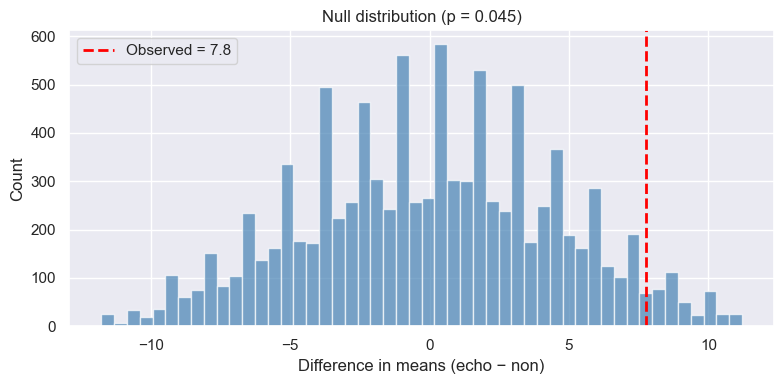

In [82]:
# Visualize the null distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_diffs, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(observed_diff, color='red', linewidth=2, linestyle='--',
           label=f'Observed = {observed_diff:.1f}')
ax.set_xlabel('Difference in means (echo − non)')
ax.set_ylabel('Count')
ax.set_title(f'Null distribution (p = {p_value:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

The **null distribution** shows what differences we'd expect if the
labels were meaningless. The **red line** is what we actually
observed. The **p-value** is the fraction of permutations where
the shuffled difference was at least as large as the observed one.

### ✏️ Exercise 1

1. Change the data so the difference is clearly non-significant
   (e.g., make all masses similar). Re-run. What does the null
   distribution look like now?

2. What happens if you increase the number of permutations from
   10,000 to 100,000 to 1,000,000? Does the p-value change much?

In [ ]:
# Your code here

---
## 3. From toy data to real sequences

Now let's apply the same logic to amino acid data. We'll load the
prestin alignment and classify species.

In [39]:
# Load prestin alignment
prestin_seqs = read_fasta(os.path.join(SUB_DIR, 'SLC26A5.trim.fa'))
names = list(prestin_seqs.keys())
aln = np.array([list(prestin_seqs[n]) for n in names])
n_seqs, n_pos = aln.shape
print(f"Prestin alignment: {n_seqs} sequences × {n_pos} positions")

# Load species classification
species_df = pd.read_table(
    os.path.join(DATA, 'species_classification.tsv'),
    comment='#'
)
species_df['taxid'] = species_df['taxid'].astype(str)
echo_lookup = dict(zip(species_df['taxid'], species_df['echolocates']))

# Label each sequence
taxids = [n.split('.')[0] for n in names]
is_echo = np.array([echo_lookup.get(t, 'no') == 'yes' for t in taxids])

n_echo = is_echo.sum()
print(f"Echolocators: {n_echo}, Non-echolocators: {n_seqs - n_echo}")

Prestin alignment: 21 sequences × 750 positions
Echolocators: 8, Non-echolocators: 13


In [40]:
species_df

,taxid,species,group,echolocates,notes
0,51298,Myotis myotis,echolocating_bat,yes,Greater mouse-eared bat (Yangochiroptera)
1,59479,Rhinolophus ferrumequinum,echolocating_bat,yes,"Greater horseshoe bat (Yinpterochiroptera, CF ..."
2,186990,Hipposideros armiger,echolocating_bat,yes,Great roundleaf bat (Yinpterochiroptera)
3,27622,Molossus molossus,echolocating_bat,yes,Velvety free-tailed bat (Yangochiroptera)
4,59472,Pipistrellus kuhlii,echolocating_bat,yes,Kuhl's pipistrelle (Yangochiroptera)
5,89673,Phyllostomus discolor,echolocating_bat,yes,Pale spear-nosed bat (Yangochiroptera)
6,109478,Myotis brandtii,echolocating_bat,yes,Brandt's bat (Yangochiroptera)
7,59463,Myotis lucifugus,echolocating_bat,yes,Little brown bat (Yangochiroptera)
8,225400,Myotis davidii,echolocating_bat,yes,David's myotis (Yangochiroptera)
9,132908,Pteropus vampyrus,non_echolocating_bat,no,Large flying fox


---
## 4. Is conservation real? Testing Shannon entropy

In Notebook 2 we computed Shannon entropy at each position. Some
positions had entropy = 0 (perfectly conserved). But is that
surprising? If an amino acid is very common (like Leucine, ~10% of
all residues), we might see columns full of L just by chance.

Let's test: at a given position, if we **shuffle the amino acids
across species**, how often do we see entropy as low as observed?

In [44]:
def shannon_entropy(column):
    """Shannon entropy of an alignment column (ignoring gaps)."""
    residues = [aa for aa in column if aa != '-']
    if not residues:
        return 0.0
    counts = Counter(residues)
    total = len(residues)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

# Pick a highly conserved position (find one with low entropy)
entropies = [shannon_entropy(list(aln[:, pos])) for pos in range(n_pos)]
conserved_positions = [i for i, e in enumerate(sorted(enumerate(entropies),
                       key=lambda x: x[1]) ) ]

# Find a position with entropy near 0 but > 0
low_ent_positions = [(i, e) for i, e in enumerate(entropies)
                     if 0 < e < 0.3]
if low_ent_positions:
    test_pos, test_ent = low_ent_positions[0]
else:
    test_pos, test_ent = 0, entropies[0]

col = list(aln[:, test_pos])
print(f"Position {test_pos}: entropy = {test_ent:.3f}")
print(f"  Amino acids: {Counter(aa for aa in col if aa != '-')}")

Position 2: entropy = 0.276
  Amino acids: Counter({np.str_('H'): 20, np.str_('R'): 1})


In [45]:
# Permutation test: shuffle amino acids at this position
n_perm = 10000
null_entropies = np.zeros(n_perm)

residues_at_pos = [aa for aa in col if aa != '-']
for i in range(n_perm):
    shuffled = list(np.random.permutation(residues_at_pos))
    null_entropies[i] = shannon_entropy(shuffled)

p_val = np.mean(null_entropies <= test_ent)
print(f"Observed entropy: {test_ent:.3f}")
print(f"P-value (entropy this low by chance): {p_val:.4f}")

Observed entropy: 0.276
P-value (entropy this low by chance): 1.0000


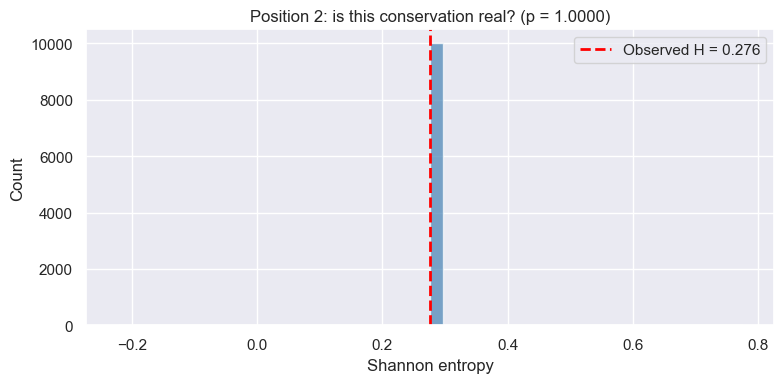

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_entropies, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(test_ent, color='red', linewidth=2, linestyle='--',
           label=f'Observed H = {test_ent:.3f}')
ax.set_xlabel('Shannon entropy')
ax.set_ylabel('Count')
ax.set_title(f'Position {test_pos}: is this conservation real? (p = {p_val:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

**Wait — what happened?** When we shuffle amino acids within the same
column, the composition doesn't change, so the entropy stays the
same! This is because entropy only depends on the *frequencies* of
amino acids, not their arrangement.

That means conservation (low entropy) is a property of amino acid
composition at a position. To test whether it's *surprising*, we'd
need to compare against a different null — like the overall amino
acid frequencies in the protein. But that's not our main question.

Our real question is about **convergence**: do *echolocators
specifically* agree on the same amino acid more than expected?

---
## 5. Testing for convergent evolution

**Conservation** = all species agree at a position.
**Convergence** = specifically the *echolocating* species agree,
more than you'd expect from a random subset of the same size.

We need a test statistic that captures this.

### 5.1 Agreement score

For a group of species at one alignment position:

$$\text{agreement} = \frac{\text{count of the most common amino acid in the group}}{\text{group size}}$$

- All echolocators have the same amino acid → agreement = 1.0
- Echolocators are split → agreement < 1.0

In [47]:
def agreement_score(residues):
    """Fraction of the most common amino acid."""
    filtered = [aa for aa in residues if aa != '-']
    if not filtered:
        return 0.0
    most_common = Counter(filtered).most_common(1)[0][1]
    return most_common / len(filtered)

# Example
print(f"['A','A','A','A','A'] → {agreement_score(['A','A','A','A','A']):.2f}")
print(f"['A','A','A','G','G'] → {agreement_score(['A','A','A','G','G']):.2f}")
print(f"['A','G','L','K','D'] → {agreement_score(['A','G','L','K','D']):.2f}")

['A','A','A','A','A'] → 1.00
['A','A','A','G','G'] → 0.60
['A','G','L','K','D'] → 0.20


### 5.2 Permutation test for convergence at one position

**Null hypothesis:** echolocators are no more similar to each other
than any random group of the same size.

**Test:** shuffle the echolocator labels, recompute agreement.

In [48]:
# Pick a position and test it
test_pos2 = 200  # try different positions
col2 = list(aln[:, test_pos2])

# Observed agreement among echolocators
echo_aas = [col2[i] for i in range(n_seqs) if is_echo[i]]
obs_agreement = agreement_score(echo_aas)
print(f"Position {test_pos2}:")
print(f"  Echolocator amino acids: {Counter(echo_aas)}")
print(f"  Observed agreement: {obs_agreement:.3f}")

# Permutation test
n_perm = 5000
null_agreements = np.zeros(n_perm)
for i in range(n_perm):
    idx = np.random.choice(n_seqs, size=n_echo, replace=False)
    null_aas = [col2[j] for j in idx]
    null_agreements[i] = agreement_score(null_aas)

p_val2 = np.mean(null_agreements >= obs_agreement)
print(f"  P-value: {p_val2:.4f}")

Position 200:
  Echolocator amino acids: Counter({np.str_('F'): 7, np.str_('-'): 1})
  Observed agreement: 1.000
  P-value: 1.0000


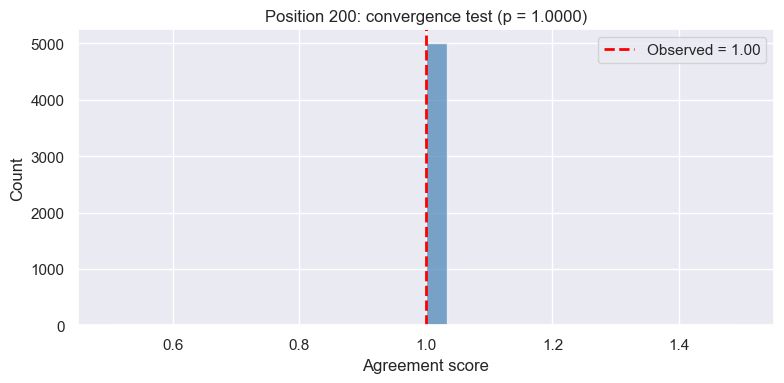

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_agreements, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(obs_agreement, color='red', linewidth=2, linestyle='--',
           label=f'Observed = {obs_agreement:.2f}')
ax.set_xlabel('Agreement score')
ax.set_ylabel('Count')
ax.set_title(f'Position {test_pos2}: convergence test (p = {p_val2:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

### ✏️ Exercise 2

Try a few different positions (e.g., 50, 100, 300, 500). Can you find
one that is clearly significant? What amino acid do the echolocators
share there?

In [ ]:
# Your code here

---
## 6. Scanning the whole alignment

Let's run the convergence test at every position and find where the
signal is.

In [50]:
print(f"Scanning {n_pos} positions ({n_perm} permutations each)...")

results = []
for pos in range(n_pos):
    col = list(aln[:, pos])
    echo_aas = [col[i] for i in range(n_seqs) if is_echo[i]]
    obs = agreement_score(echo_aas)

    count = 0
    for _ in range(n_perm):
        idx = np.random.choice(n_seqs, size=n_echo, replace=False)
        if agreement_score([col[j] for j in idx]) >= obs:
            count += 1

    results.append({'position': pos, 'agreement': obs, 'pvalue': count / n_perm})
    if (pos + 1) % 100 == 0:
        print(f"  ... {pos+1}/{n_pos}")

results_df = pd.DataFrame(results)
print("Done!")

Scanning 750 positions (5000 permutations each)...
  ... 100/750
  ... 200/750
  ... 300/750
  ... 400/750
  ... 500/750
  ... 600/750
  ... 700/750
Done!


In [51]:
n_sig = (results_df['pvalue'] < 0.05).sum()
n_sig_strict = (results_df['pvalue'] < 0.01).sum()
print(f"Positions with p < 0.05: {n_sig} / {n_pos}")
print(f"Positions with p < 0.01: {n_sig_strict} / {n_pos}")

# How many would we expect by chance at p < 0.05?
print(f"Expected by chance at p < 0.05: {0.05 * n_pos:.0f}")

Positions with p < 0.05: 13 / 750
Positions with p < 0.01: 3 / 750
Expected by chance at p < 0.05: 38


### Manhattan plot

Show the −log₁₀(p-value) at each position. Points above the
significance line are candidate convergent sites.

/var/folders/bg/mb65kwgx0_vbvks48sb6m1jw0000gp/T/ipykernel_14956/4270514721.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/bg/mb65kwgx0_vbvks48sb6m1jw0000gp/T/ipykernel_14956/4270514721.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/mambaforge/base/envs/convergent-evo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/base/envs/convergent-evo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


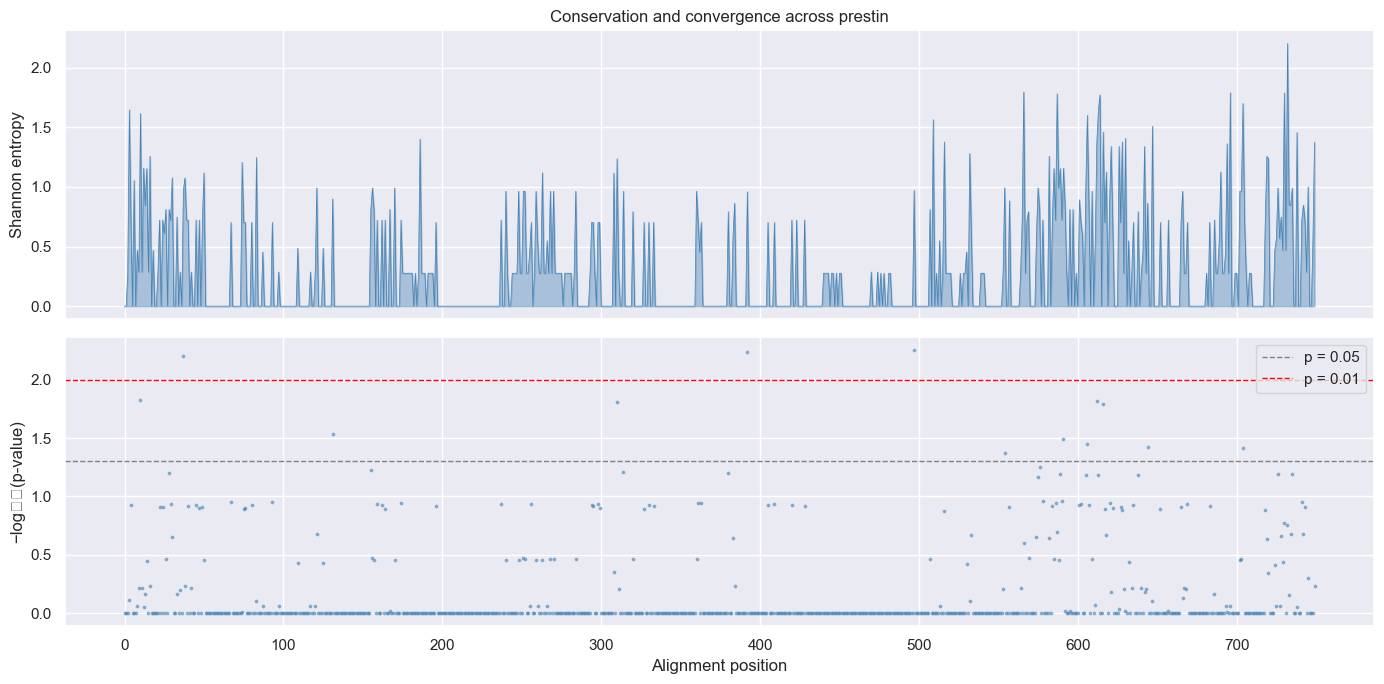

In [52]:
# Replace p=0 with a small number to avoid log(0)
pvals = results_df['pvalue'].replace(0, 1 / (n_perm + 1))
neg_log_p = -np.log10(pvals)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: entropy profile
axes[0].fill_between(range(n_pos), entropies, alpha=0.4, color='steelblue')
axes[0].plot(range(n_pos), entropies, linewidth=0.5, color='steelblue')
axes[0].set_ylabel('Shannon entropy')
axes[0].set_title('Conservation and convergence across prestin')

# Bottom: convergence signal
axes[1].scatter(range(n_pos), neg_log_p, s=3, c='steelblue', alpha=0.5)
axes[1].axhline(-np.log10(0.05), color='gray', linewidth=1, linestyle='--',
                label='p = 0.05')
axes[1].axhline(-np.log10(0.01), color='red', linewidth=1, linestyle='--',
                label='p = 0.01')
axes[1].set_xlabel('Alignment position')
axes[1].set_ylabel('−log₁₀(p-value)')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✏️ Exercise 3

1. Are the convergent positions (p < 0.01) concentrated in any
   region of the alignment, or scattered throughout?

2. Look at the entropy of convergent positions. Are they in conserved
   or variable regions?

In [ ]:
# Your code here

---
## 7. Validation: is prestin special?

We found convergent sites in prestin. But how do we know this signal
is real and not an artifact? One approach: run the **exact same test**
on other SLC26 subfamilies that have **no reason** to show convergence
in echolocating species (e.g., SLC26A1, SLC26A3, SLC26A6).

If prestin is truly convergent, it should have **more significant
positions** than these control subfamilies.

In [53]:
def count_convergent_sites(aln_path, is_echo_lookup, threshold=0.05, n_perm=1000):
    """Run convergence scan on one subfamily alignment.
    Returns number of significant positions."""
    seqs = read_fasta(aln_path)
    if len(seqs) < 5:
        return None

    names = list(seqs.keys())
    aln = np.array([list(seqs[n]) for n in names])
    taxids = [n.split('.')[0] for n in names]
    is_echo = np.array([is_echo_lookup.get(t, 'no') == 'yes' for t in taxids])
    n_echo = is_echo.sum()

    if n_echo < 2:
        return None

    n_pos = aln.shape[1]
    n_sig = 0
    for pos in range(n_pos):
        col = list(aln[:, pos])
        echo_aas = [col[i] for i in range(len(names)) if is_echo[i]]
        obs = agreement_score(echo_aas)

        count = 0
        for _ in range(n_perm):
            idx = np.random.choice(len(names), size=n_echo, replace=False)
            if agreement_score([col[j] for j in idx]) >= obs:
                count += 1
        if count / n_perm < threshold:
            n_sig += 1

    return n_sig

In [54]:
# Test prestin and control subfamilies
controls = ['SLC26A1', 'SLC26A3', 'SLC26A6']
echo_lookup_str = dict(zip(species_df['taxid'].astype(str), species_df['echolocates']))

print("Scanning subfamilies for convergent sites (1000 permutations)...")
print("This may take a few minutes.\n")

comparison = {}
for sub in ['SLC26A5'] + controls:
    trim_path = os.path.join(SUB_DIR, f'{sub}.trim.fa')
    if not os.path.exists(trim_path):
        print(f"  {sub}: alignment not found, skipping")
        continue

    seqs = read_fasta(trim_path)
    n_sites = count_convergent_sites(trim_path, echo_lookup_str,
                                     threshold=0.05, n_perm=1000)
    aln_len = len(next(iter(seqs.values())))
    comparison[sub] = {'n_significant': n_sites, 'alignment_length': aln_len,
                       'fraction': n_sites / aln_len if n_sites else 0}
    print(f"  {sub}: {n_sites}/{aln_len} significant positions "
          f"({100*comparison[sub]['fraction']:.1f}%)")

Scanning subfamilies for convergent sites (1000 permutations)...
This may take a few minutes.

  SLC26A5: 13/750 significant positions (1.7%)
  SLC26A1: 34/788 significant positions (4.3%)
  SLC26A3: 27/759 significant positions (3.6%)
  SLC26A6: 33/791 significant positions (4.2%)


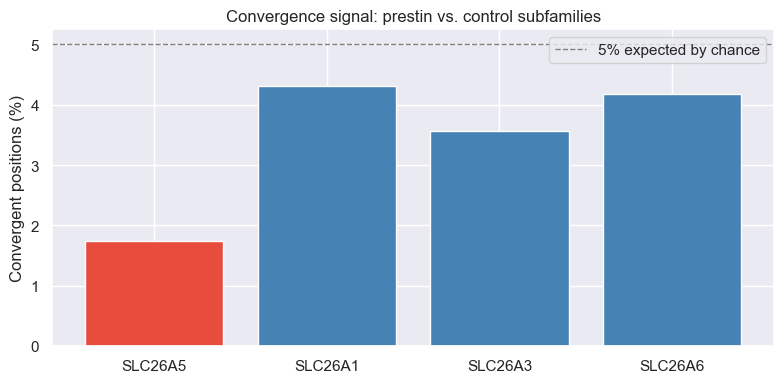

In [55]:
# Plot the comparison
comp_df = pd.DataFrame(comparison).T
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if s == 'SLC26A5' else 'steelblue' for s in comp_df.index]
ax.bar(comp_df.index, comp_df['fraction'] * 100, color=colors)
ax.set_ylabel('Convergent positions (%)')
ax.set_title('Convergence signal: prestin vs. control subfamilies')
ax.axhline(5, color='gray', linewidth=1, linestyle='--', label='5% expected by chance')
ax.legend()
plt.tight_layout()
plt.show()

If prestin (red) shows significantly more convergent sites than the
control subfamilies (blue), that supports the hypothesis that
echolocating species have convergently evolved specific amino acid
changes in prestin.

The gray line at 5% marks what we'd expect by chance alone (since
we used p < 0.05 as our threshold). Subfamilies near or below this
line show no convergence signal.

---
## 8. Summary and connection to the literature

**What we did:**
- Learned permutation tests through a simple example
- Applied them to detect amino acid convergence in prestin
- Validated by showing that control subfamilies lack the signal

**What a more rigorous analysis would add:**
- **Phylogenetic correction:** closely related species share amino
  acids by inheritance, not convergence. A proper test accounts for
  the species tree (see Zou & Zhang 2015, Thomas & Hahn 2015).
- **Ancestral state reconstruction:** distinguish true convergence
  (independent gains) from shared ancestral states.
- **Multiple testing correction:** with hundreds of positions tested,
  we should apply Benjamini-Hochberg FDR correction.

**Connection to Parker et al. (2013):**
[Parker et al.](https://www.nature.com/articles/nature12511) did a
genome-wide analysis across 22 mammals and found widespread convergent
evolution in echolocating species — not just in prestin but across
many genes involved in hearing.

---
## 9. Save results for the assignment

In [56]:
results_path = os.path.join(DATA, 'prestin_convergence_results.csv')
results_df.to_csv(results_path, index=False)
print(f"Saved convergence results → {results_path}")

entropy_df = pd.DataFrame({'position': range(n_pos), 'entropy': entropies})
entropy_path = os.path.join(DATA, 'prestin_entropy.csv')
entropy_df.to_csv(entropy_path, index=False)
print(f"Saved entropy values → {entropy_path}")

Saved convergence results → ../data/prestin_convergence_results.csv
Saved entropy values → ../data/prestin_entropy.csv
